# Hybrid Pipeline

This notebook is the complete Hybrid pipeline: it combines the winning Pipeline B Uniform LBP texture features with nine HSV colour moments, then trains Pipeline A's selected classifiers: LightGBM for fruit type and CatBoost for ripeness. Validation is used only for tuning; the test split is evaluated once after the configuration is locked.

In [1]:
import os
from pathlib import Path
import json
import sys
from typing import Any, Callable

import cv2
import joblib
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'src').is_dir())
if str(PROJECT_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from classification.fruit_type_a import predict_lightgbm, train_lightgbm
from feature_extraction.feature_extraction_b import extract_lbp
from feature_extraction.hsv_colour_moments import extract_hsv_colour_moments
from morphology.morphology_b import apply_morphological_closing
from classification.ripeness_a import predict_catboost, train_catboost
from preprocessing.preprocessing_b import preprocess_image
from segmentation.segmentation_b import segment_image
from shared.initial_image_standardization import scan_dataset, standardize_image
from shared.roi_extraction_cca import extract_fruit_rois
from shared.roi_standardization import standardize_roi, standardize_roi_mask

from evaluation.classification_metrics import (
    evaluate_classification, plot_confusion_matrix, select_best_classification_configuration,
)

RESULTS_ROOT = PROJECT_ROOT / 'results' / 'hybrid'
FEATURE_CACHE_DIR = RESULTS_ROOT / 'generated_features'
DATASET_ROOT = Path(os.environ.get('DATASET_ROOT', Path.home() / 'Downloads' / 'final_dataset'))
HSV_FEATURE_COUNT = 9
INVALID_LABELS = {'train', 'test', 'validation', 'images', 'labels'}

SELECTED_ALGORITHMS = {
    'standardization': 'Existing 512x512 size-preserving standardization',
    'preprocessing': 'Pipeline A Median Filter (3x3)',
    'segmentation': 'Pipeline A Otsu Thresholding',
    'morphology': 'Pipeline A Morphological Opening (ellipse 3x3)',
    'detection': 'Selected from saved A/B detection evaluation',
    'counting': 'Selected from saved A/B counting evaluation',
    'roi_extraction': 'Existing ROI extraction matching selected detector',
    'feature_extraction': 'Pipeline B Uniform LBP + HSV Colour Moments',
    'fruit_type_classifier': 'Pipeline A LightGBM',
    'ripeness_classifier': 'Pipeline A CatBoost',
}
FRUIT_TYPE_CANDIDATES = (
    {'n_estimators': 150, 'learning_rate': 0.05, 'num_leaves': 31, 'max_depth': -1},
    {'n_estimators': 250, 'learning_rate': 0.05, 'num_leaves': 31, 'max_depth': -1},
)
RIPENESS_CANDIDATES = (
    {'iterations': 150, 'learning_rate': 0.05, 'depth': 6, 'l2_leaf_reg': 3},
    {'iterations': 250, 'learning_rate': 0.05, 'depth': 6, 'l2_leaf_reg': 3},
)
print(f'Project root: {PROJECT_ROOT}')


Project root: c:\Users\Hwang\Documents\GitHub\IP-Asignment


## Load aligned feature matrices

The notebook runs the complete Hybrid training flow. It requires aligned Pipeline B LBP matrices and HSV matrices for `train`, `validation`, and `test`. Each HSV matrix must have nine columns and exactly the same ROI order as its matching LBP matrix.

In [2]:
def load_array(directory: Path, filename: str) -> np.ndarray:
    path = directory / filename
    if not path.exists():
        raise FileNotFoundError(f'Missing {path}. Pipeline B must export the matching {filename} split before this Hybrid notebook can train or evaluate it.')
    return np.load(path, allow_pickle=True)

def labels_for_record(record: dict) -> list[tuple[str, str]]:
    path = Path(record['path'])
    parts = path.relative_to(DATASET_ROOT).parts
    split_index = next(i for i, part in enumerate(parts) if part.lower() == record['split'])
    if record['fruit_group'] == 'single_fruit':
        return [(parts[split_index + 1], parts[split_index + 2])]
    label_path = DATASET_ROOT / 'multiple_fruit' / record['split'] / 'labels' / f'{path.stem}.txt'
    if not label_path.exists():
        raise FileNotFoundError(f'Missing labels for {path.name}: {label_path}')
    return [tuple(line.split(maxsplit=1)) for line in label_path.read_text(encoding='utf-8').splitlines() if line.strip()]

def extract_pipeline_b_features(record: dict) -> tuple[np.ndarray, np.ndarray, list[tuple[str, str]]]:
    _, standardized_image, _ = standardize_image(record)
    if standardized_image is None:
        raise ValueError(f'Unable to read {record["path"]}')
    filtered_image, _ = preprocess_image(standardized_image, kernel_size=3)
    threshold_mask, _, _ = segment_image(filtered_image, threshold=128)
    refined_mask, _, _ = apply_morphological_closing(threshold_mask, kernel_size=3)
    rois, _, _ = extract_fruit_rois(standardized_image, refined_mask, min_component_area=7000)
    if not rois:
        return np.empty((0, 10), dtype=np.float32), np.empty((0, HSV_FEATURE_COUNT), dtype=np.float32), []
    labels = labels_for_record(record)
    # This is the Pipeline A/B feature-extraction convention: one image label
    # is assigned to every ROI detected in that image.
    labels = labels * len(rois)
    lbp_rows, hsv_rows = [], []
    for item in rois:
        roi, roi_mask = item['roi'], item['roi_mask']
        standardized_roi, _, _ = standardize_roi(roi)
        standardized_mask = standardize_roi_mask(roi_mask)
        lbp_rows.append(extract_lbp(standardized_roi, standardized_mask, radius=3))
        hsv_rows.append(extract_hsv_colour_moments(roi, roi_mask))
    return np.vstack(lbp_rows), np.vstack(hsv_rows), labels

def build_feature_cache() -> None:
    required = [FEATURE_CACHE_DIR / f'{split}_{name}.npy' for split in ('train', 'validation', 'test') for name in ('features', 'hsv_features', 'fruit_type_labels', 'ripeness_labels')]
    if all(path.exists() for path in required):
        return
    if not DATASET_ROOT.is_dir():
        raise FileNotFoundError(f'Dataset root not found: {DATASET_ROOT}. Set DATASET_ROOT before running this notebook.')
    records = scan_dataset(DATASET_ROOT)
    FEATURE_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    for split in ('train', 'validation', 'test'):
        lbp_rows, hsv_rows, fruit_labels, ripeness_labels = [], [], [], []
        # Multi-fruit .txt labels are per fruit, while CCA produces an unrelated
        # number of components. They cannot be aligned without bounding boxes,
        # so use the same path-derived labels as the Pipeline A/B notebooks.
        for record in (item for item in records if item['split'] == split and item['fruit_group'] == 'single_fruit'):
            lbp, hsv, labels = extract_pipeline_b_features(record)
            lbp_rows.append(lbp); hsv_rows.append(hsv)
            fruit_labels.extend(fruit for fruit, _ in labels)
            ripeness_labels.extend(ripeness for _, ripeness in labels)
        if not lbp_rows:
            raise ValueError(f'No feature rows were generated for the {split} split.')
        np.save(FEATURE_CACHE_DIR / f'{split}_features.npy', np.vstack(lbp_rows).astype(np.float32))
        np.save(FEATURE_CACHE_DIR / f'{split}_hsv_features.npy', np.vstack(hsv_rows).astype(np.float32))
        np.save(FEATURE_CACHE_DIR / f'{split}_fruit_type_labels.npy', np.asarray(fruit_labels, dtype=str))
        np.save(FEATURE_CACHE_DIR / f'{split}_ripeness_labels.npy', np.asarray(ripeness_labels, dtype=str))
        print(f'Generated Pipeline B + HSV features for {split}: {len(fruit_labels)} ROI(s)')

build_feature_cache()

def validate_labels(labels: np.ndarray, split_name: str) -> None:
    invalid = sorted({str(value).strip().lower() for value in np.asarray(labels).ravel()} & INVALID_LABELS)
    if invalid:
        raise ValueError(f'{split_name} labels contain directory names {invalid}. Fix label parsing before training.')

def concatenate_hybrid_features(lbp_features: np.ndarray, hsv_features: np.ndarray) -> np.ndarray:
    lbp_features = np.asarray(lbp_features, dtype=np.float32)
    hsv_features = np.asarray(hsv_features, dtype=np.float32)
    if lbp_features.ndim != 2 or hsv_features.ndim != 2 or len(lbp_features) != len(hsv_features):
        raise ValueError('LBP and HSV matrices must be two-dimensional with matching rows.')
    if hsv_features.shape[1] != HSV_FEATURE_COUNT:
        raise ValueError(f'HSV feature matrix must contain {HSV_FEATURE_COUNT} columns.')
    return np.hstack((lbp_features, hsv_features)).astype(np.float32, copy=False)

baseline_train = load_array(FEATURE_CACHE_DIR, 'train_features.npy')
baseline_validation = load_array(FEATURE_CACHE_DIR, 'validation_features.npy')
baseline_test = load_array(FEATURE_CACHE_DIR, 'test_features.npy')
hsv_train = load_array(FEATURE_CACHE_DIR, 'train_hsv_features.npy')
hsv_validation = load_array(FEATURE_CACHE_DIR, 'validation_hsv_features.npy')
hsv_test = load_array(FEATURE_CACHE_DIR, 'test_hsv_features.npy')
fruit_train = load_array(FEATURE_CACHE_DIR, 'train_fruit_type_labels.npy')
fruit_validation = load_array(FEATURE_CACHE_DIR, 'validation_fruit_type_labels.npy')
fruit_test = load_array(FEATURE_CACHE_DIR, 'test_fruit_type_labels.npy')
ripeness_train = load_array(FEATURE_CACHE_DIR, 'train_ripeness_labels.npy')
ripeness_validation = load_array(FEATURE_CACHE_DIR, 'validation_ripeness_labels.npy')
ripeness_test = load_array(FEATURE_CACHE_DIR, 'test_ripeness_labels.npy')

for name, labels in {'fruit train': fruit_train, 'fruit validation': fruit_validation, 'fruit test': fruit_test, 'ripeness train': ripeness_train, 'ripeness validation': ripeness_validation, 'ripeness test': ripeness_test}.items():
    validate_labels(labels, name)

train_features = concatenate_hybrid_features(baseline_train, hsv_train)
validation_features = concatenate_hybrid_features(baseline_validation, hsv_validation)
test_features = concatenate_hybrid_features(baseline_test, hsv_test)
display(pd.DataFrame({'split': ['train', 'validation', 'test'], 'ROIs': [len(train_features), len(validation_features), len(test_features)], 'hybrid features': [train_features.shape[1]] * 3}))


Generated Pipeline B + HSV features for train: 54160 ROI(s)
Generated Pipeline B + HSV features for validation: 7607 ROI(s)
Generated Pipeline B + HSV features for test: 8793 ROI(s)


,split,ROIs,hybrid features
0,train,54160,19
1,validation,7607,19
2,test,8793,19


,Task,Best parameters,Test accuracy,Test macro F1
0,Fruit type,"{'n_estimators': 250, 'learning_rate': 0.05, '...",0.826339,0.71666
1,Ripeness,"{'iterations': 250, 'learning_rate': 0.05, 'de...",0.636415,0.61812


Hybrid results saved to: c:\Users\Hwang\Documents\GitHub\IP-Asignment\results\hybrid


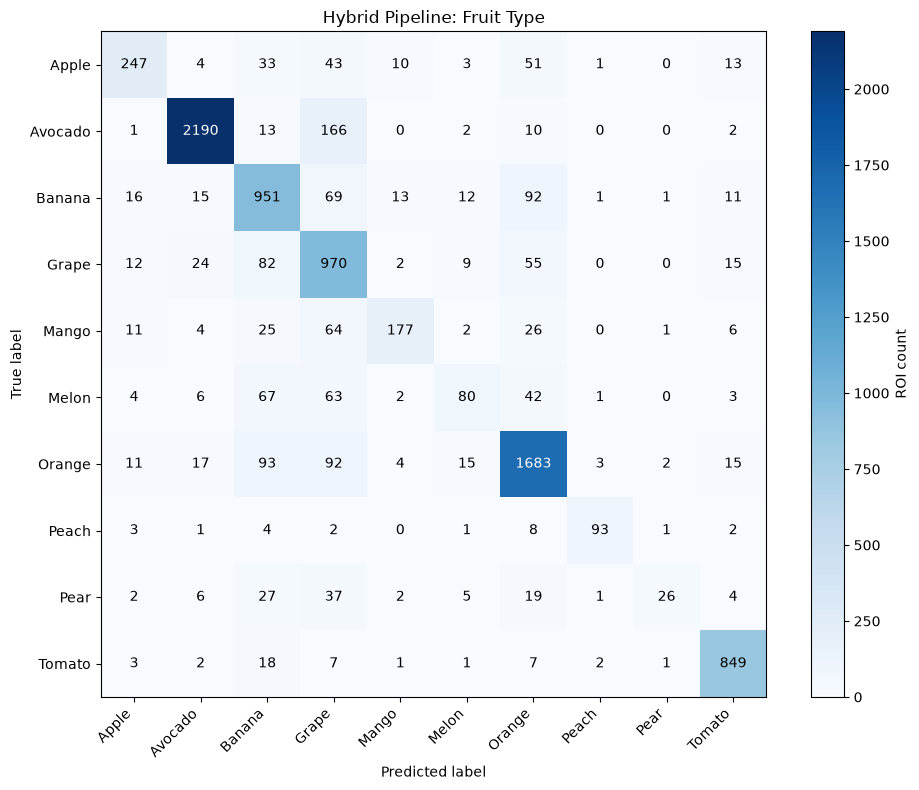

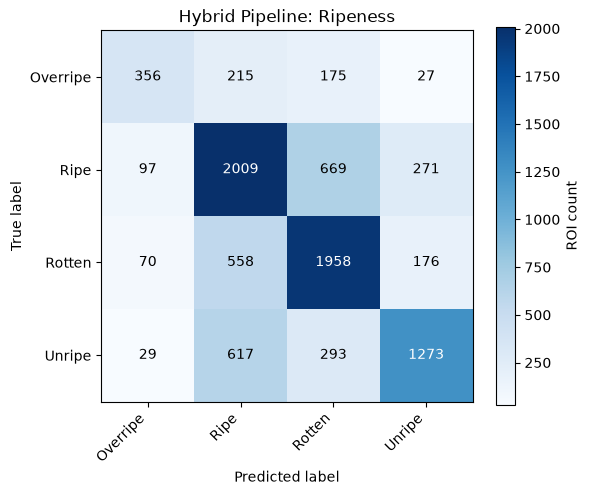

In [5]:
def save_json(path: Path, payload: dict[str, Any]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(payload, indent=2), encoding='utf-8')

def train_task(task_name, train_labels, validation_labels, test_labels, candidates, trainer, predictor):
    tuning_records = []
    for parameters in candidates:
        model, training_time = trainer(train_features, train_labels, parameters)
        predictions, prediction_time = predictor(model, validation_features)
        tuning_records.append({'parameters': parameters, **evaluate_classification(validation_labels, predictions, training_time, prediction_time)})
    selected = select_best_classification_configuration(tuning_records)
    final_features = np.vstack((train_features, validation_features))
    final_labels = np.concatenate((train_labels, validation_labels))
    model, training_time = trainer(final_features, final_labels, selected['parameters'])
    predictions, prediction_time = predictor(model, test_features)
    metrics = evaluate_classification(test_labels, predictions, training_time, prediction_time)
    task_dir = RESULTS_ROOT / task_name
    task_dir.mkdir(parents=True, exist_ok=True)
    joblib.dump(model, task_dir / f'hybrid_{task_name}_model.joblib')
    np.save(task_dir / f'hybrid_{task_name}_test_predictions.npy', predictions)
    save_json(task_dir / f'hybrid_{task_name}_best_parameters.json', selected['parameters'])
    save_json(task_dir / f'hybrid_{task_name}_tuning_results.json', {'validation_results': tuning_records})
    save_json(task_dir / f'hybrid_{task_name}_test_metrics.json', metrics)
    return selected, metrics

RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
save_json(RESULTS_ROOT / 'selected_algorithms.json', SELECTED_ALGORITHMS)
save_json(RESULTS_ROOT / 'hybrid_feature_configuration.json', {'baseline_feature_algorithm': 'Pipeline B Uniform LBP', 'hsv_colour_moments': HSV_FEATURE_COUNT, 'hybrid_feature_size': int(train_features.shape[1])})
np.save(RESULTS_ROOT / 'hybrid_train_features.npy', train_features)
np.save(RESULTS_ROOT / 'hybrid_validation_features.npy', validation_features)
np.save(RESULTS_ROOT / 'hybrid_test_features.npy', test_features)

fruit_selection, fruit_metrics = train_task('fruit_type_classification', fruit_train, fruit_validation, fruit_test, FRUIT_TYPE_CANDIDATES, train_lightgbm, predict_lightgbm)
ripeness_selection, ripeness_metrics = train_task('ripeness_classification', ripeness_train, ripeness_validation, ripeness_test, RIPENESS_CANDIDATES, train_catboost, predict_catboost)
summary = {'selected_algorithms': SELECTED_ALGORITHMS, 'fruit_type': fruit_metrics, 'ripeness': ripeness_metrics}
save_json(RESULTS_ROOT / 'hybrid_summary.json', summary)
display(pd.DataFrame([{'Task': 'Fruit type', 'Best parameters': fruit_selection['parameters'], 'Test accuracy': fruit_metrics['accuracy'], 'Test macro F1': fruit_metrics['macro_f1_score']}, {'Task': 'Ripeness', 'Best parameters': ripeness_selection['parameters'], 'Test accuracy': ripeness_metrics['accuracy'], 'Test macro F1': ripeness_metrics['macro_f1_score']}]))
plot_confusion_matrix(fruit_metrics, 'Hybrid Pipeline: Fruit Type');
plot_confusion_matrix(ripeness_metrics, 'Hybrid Pipeline: Ripeness');
print(f'Hybrid results saved to: {RESULTS_ROOT}')
